This notebook runs **normative modeling** of **functional connectivity** data **per network** as a function of **age**. This enables the build of **normative charts of functional connectivity in healthy aging**, embracing both diversity and uncertainty from a cohort of 1000 healthy subjects. A battery of models (statistical frameorks) are fitted to the empirical data through Hierarchical Bayesian Regression proposed in the package Predictive Clinical Neuroscience toolkit (pcntoolkit, https://pcntoolkit.readthedocs.io/en/latest/). The trade-off between predictive power and complexity of the models is assessed through bayesian model comparison, guiding for the choice of an adequate normative model describing this empirical data of functional connectivity. 

In [1]:
import warnings
#removing annoying warnings related to pymc dependencies in pcntoolkit 
warnings.filterwarnings("ignore", category=FutureWarning)

import os 
import numpy as np
import pandas as pd 
import matplotlib.pyplot as plt
plt.rcParams.update({'axes.labelsize':14, 'axes.titlesize':16})
import pickle
import pcntoolkit as ptk  
import arviz as az
from itertools import product


from funcs import *

## Loading the data

Here a .json containing demographic data of subjects and their FC matrices computed from BOLD FMRI recordings.

In [2]:
cwd = os.getcwd()

In [3]:
fc_df = pd.read_json('FUNC_df.json')

In [4]:
fc_df.isna().sum()

SubjectID    0
Age          1
FC           0
FCD          0
dtype: int64

In [5]:
fc_df = fc_df.dropna()
fc_df['FC'] = fc_df['FC'].apply(np.array)

We break down the functional connectivity into the 7 networks 

In [9]:
with open('../Structural/Schaefer2018_100Parcels_7Networks_order_info.txt', 'r') as f:
    lines = f.read().splitlines()

In [10]:
net_labels = lines[::2]
roi_index = [int(l[:l.find(' ')]) for l in lines[1::2]]
roi_index = np.array(roi_index) - 1

In [11]:
net_df = pd.DataFrame({'label': net_labels, 'index': roi_index})
net_df['hemis'] = net_df.label.apply(lambda x: x[10:12])
net_df['net'] = net_df.label.apply(lambda x: x[13:][:x[13:].find('_')])
net_indices = net_df.groupby('net')['index'].apply(list)

In [13]:
net_matching = {}
for net in net_indices.index.values :
    net_matching[net] = np.ix_(net_indices[net], net_indices[net])

In [19]:
for net in net_matching.keys() :
    fc_df['FC_' + net] = fc_df['FC'].apply(lambda x: x[net_matching[net]])
    fc_df['Mean_FC_' + net] = fc_df['FC_' + net].apply(np.mean)
    fc_df['Var_FC_' + net] = fc_df['FC_' + net].apply(np.var)

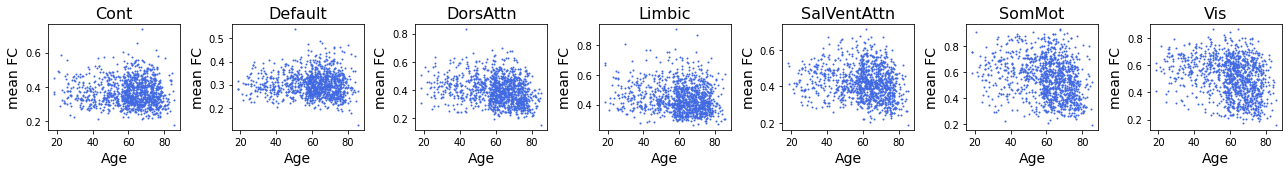

In [22]:
fig, ax = plt.subplots(ncols=7, figsize=(18, 2.5))
for i, net in enumerate(net_matching.keys()) :
    ax[i].scatter(fc_df['Age'], fc_df['Mean_FC_' + net], s=1, color='royalblue')
    ax[i].set(title=net, xlabel='Age', ylabel='mean FC')
fig.tight_layout()

We fit different parameterizations of generalized additive models (GAM) and GAMLSS (GAM of location scale and shape) to each of the network-FC as a function of age and we select the best fit based on model comparison. GAM het means GAM with heteroscedastic noise and GAMLSS sigma, eps, delta respectively mean heteroscedastic noise, asymetry and tail. More precisely, the models we fit are :

* "gam_hom" : $y \sim N(\mu,\sigma), \mu = f(x)$
* "gam_het" : $y \sim N(\mu,\sigma), \mu = f_1(x), \sigma = f_2(x)$
* "gamlss_sig" : $y \sim SHASH(\mu, \sigma, \epsilon, \delta), \mu = f_1(x), \sigma = f_2(x)$
* "gamlss_sig_eps" $y \sim SHASH(\mu, \sigma, \epsilon, \delta), \mu = f_1(x), \sigma = f_2(x), \epsilon = f_3(x)$
* "gamlss_sig_del" : $y \sim SHASH(\mu, \sigma, \epsilon, \delta), \mu = f_1(x), \sigma = f_2(x), \delta = f_4(x)$
* "gamlss_sig_eps" : $y \sim SHASH(\mu, \sigma, \epsilon, \delta), \mu = f_1(x), \sigma = f_2(x), \epsilon = f_3(x), \delta = f_4(x)$

where $f$ are spline functions.

In [23]:
x_str = 'Age' 
nm_dict = dict(name=[], nm=[])
for net in net_matching.keys() :
    y_str = 'Mean_FC_' + net
    models_dict, compare = run_all_and_compare(fc_df, x_str, y_str, reg_type='gamlss')
    name = get_best(compare)
    print(net, ': best = ', name)
    nm_dict['name'].append(name)

Processing data in /media/tng/3771af5d-6826-432e-8c86-960e3cef1d6c/tng/nina/1000brains/Pseudo/regression/reg_data/Mean_FC_Cont.pkl
Estimating model  1 of 1
Could not find batch-effects file! Initilizing all as zeros ...


Auto-assigning NUTS sampler...
Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [slope_mu, intercept_mu, mu_sigma, sigma_sigma, sigma]


Output()

Sampling 4 chains for 1_000 tune and 1_000 draw iterations (4_000 + 4_000 draws total) took 166 seconds.
There were 56 divergences after tuning. Increase `target_accept` or reparameterize.


Processing data in /media/tng/3771af5d-6826-432e-8c86-960e3cef1d6c/tng/nina/1000brains/Pseudo/regression/reg_data/Mean_FC_Cont.pkl
Estimating model  1 of 1
Could not find batch-effects file! Initilizing all as zeros ...


...

Sampling: [y_like]


Output()

/media/tng/3771af5d-6826-432e-8c86-960e3cef1d6c/tng/nina/1000brains/Pseudo/regression/funcs.py:280: RuntimeWarning: divide by zero encountered in log
  return np.log(lik)
/home/tng/.local/lib/python3.10/site-packages/arviz/stats/stats.py:1043: RuntimeWarning: overflow encountered in exp
  weights = 1 / np.exp(len_scale - len_scale[:, None]).sum(axis=1)
/home/tng/.local/lib/python3.10/site-packages/arviz/stats/stats.py:976: RuntimeWarning: invalid value encountered in subtract
  x -= np.max(x)
/home/tng/.local/lib/python3.10/site-packages/arviz/stats/stats.py:795: UserWarning: Estimated shape parameter of Pareto distribution is greater than 0.70 for one or more samples. You should consider using a more robust model, this is because importance sampling is less likely to work well if the marginal posterior and LOO posterior are very different. This is more likely to happen with a non-robust model and highly influential observations.
  warnings.warn(


Vis : best =  gam_het


/home/tng/.local/lib/python3.10/site-packages/arviz/stats/stats.py:795: UserWarning: Estimated shape parameter of Pareto distribution is greater than 0.70 for one or more samples. You should consider using a more robust model, this is because importance sampling is less likely to work well if the marginal posterior and LOO posterior are very different. This is more likely to happen with a non-robust model and highly influential observations.
  warnings.warn(


In [36]:
for name in nm_dict['name'] :
    with open("./reg_fits/x=" + x_str + "_y=" + y_str + "_fit_" + name + ".pkl",'rb') as file :
        nm = pickle.load(file)
    nm_dict['nm'].append(nm)

We plot the best fit for each network-FC

Sampling: [y_like]


Output()

Sampling: [y_like]


Output()

Sampling: [y_like]


...

Output()

Sampling: [y_like]


Output()

Sampling: [y_like]


Output()

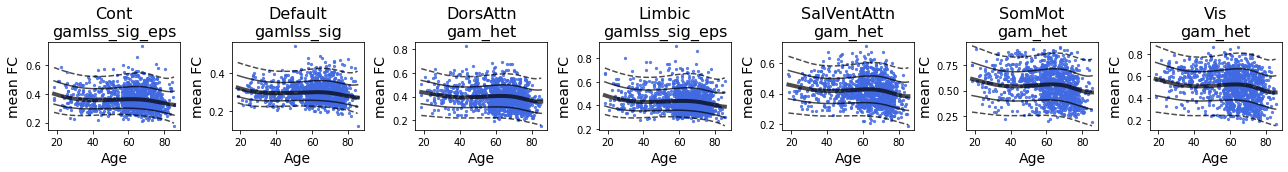

In [42]:
inscaler = ptk.util.utils.scaler('standardize')
outscaler = ptk.util.utils.scaler('standardize')

fig, ax = plt.subplots(ncols=7, figsize=(18, 2.5))
for i, net in enumerate(net_matching.keys()) :
    y_str = 'Mean_FC_' + net
    plot_quantiles(nm_dict['nm'][i], fc_df, x_str, y_str, inscaler, outscaler, n_qs=2, ax=ax[i])
    ax[i].set(title=net + '\n' + nm_dict['name'][i], xlabel='Age', ylabel='mean FC')
fig.tight_layout()